## Les modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.pyplot import*
import pandas as pd
import nbimporter
from Normalisation import*
from IPython.display import clear_output
from IPython.display import clear_output, display
import nbimporter
import matplotlib.animation as ani
#import tikzplotlib                                                     # une methode pour installer une librairire est de tape !pip install tikzplotlib


## Données et normalistion

In [2]:
def donne_exerce(m,pas):
    
    T=np.array([1+i*pas for i in range(m)])
    V=np.array([2*T[i]-1+np.random.normal(0,5) for i in range(0,m)])
    T=normalisation('min_max',T)
    V=normalisation('min_max',V)
    
    def f(a,b,T,V):
        s=[(V[i]-a*T[i]-b)**2 for i in range(m)]
        return np.sum(s)/m
        
    return T,V,f


## algorithme de la descente du gradient.

In [3]:
def GDS(T,V,nbr_iter=2000,pas=0.1,a=[0.6],b=[0.9]):
    m=len(T)
    dJa=[np.sum([T[i]*(V[i]-a[0]*T[i]-b[0]) for i in range(m)])]
    dJb=[np.sum([(V[i]-a[0]*T[i]-b[0]) for i in range(m)])]
    
    for j in range(nbr_iter):
        a.append(a[j]+pas*(2/m)*dJa[j])
        b.append(b[j]+pas*(2/m)*dJb[j])
    
        dJa.append(np.sum([T[i]*(V[i]-a[j+1]*T[i]-b[j+1]) for i in range(m)]))
        dJb.append(np.sum([(V[i]-a[j+1]*T[i]-b[j+1]) for i in range(m)]))
    return a,b

## pour la visualisation 3D

In [4]:
def Mallaige_de_fonction(T,V,f,n=10):
    x=np.linspace(-n,n,n)
    y=np.linspace(-n,n,n)
    x=normalisation('min_max',x)
    y=normalisation('min_max',y)
    X,Y=np.meshgrid(x,y)
    Z=np.zeros((n,n))
    for i in range(n):
        for j in range(n):
            Z[i,j]=f(X[i,j],Y[i,j],T,V)
    return X,Y,Z

## visualisation graphique

In [6]:
def grapheGDS(T,V,f,X,Y,Z,a,b,j):
    
    a1=np.cov(T,V)[0,1]/np.var(T)
    b1=np.mean(V)-np.mean(T)*a1
    c=[]
    for i in range(len(a)):
        c.append(f(a[i],b[i],T,V))
        
    fig=plt.figure(figsize=(8,8))
    ax3=fig.add_subplot(1,2,1,projection='3d')
    #ax3.grid(False)
    ax3.plot_surface(X,Y,Z,edgecolor='k',cmap='viridis',rstride=5,cstride=5,alpha=0.5)                 #cmap='viridis',,color='w'alpha=0,zorder=5,cmap='viridis'
    ax3.plot(a1,b1,f(a1,b1,T,V),c='violet',marker='o',zorder=5)
    ax3.plot(a[:],b[:],c[:],c='r',marker='o',zorder=15)
    ax3.plot(a[-1],b[-1],c[-1],c='g',marker='o',zorder=15)
    ax3.text(a1+0.08,b1,f(a1,b1,T,V),'A')
    ax3.text(a[-1]+0.08,b[-1],c[-1],'B')
    ax3.set_ylabel("Temps(en s)")
    ax3.set_xlabel("V(en %)")
    
    ax2=fig.add_subplot(1,2,2)
    ax2.contour(X,Y,Z,colors='black') 
    ax2.scatter(a[:i],b[:i],s=5,c='r')
    ax2.scatter(a[-1],b[-1],s=20,c='g')
    ax2.scatter(a1,b1,s=40,c='violet')
    fig.savefig(f'DGS{j}',bbox_inches='tight')
    
    return plt.show(),c
     

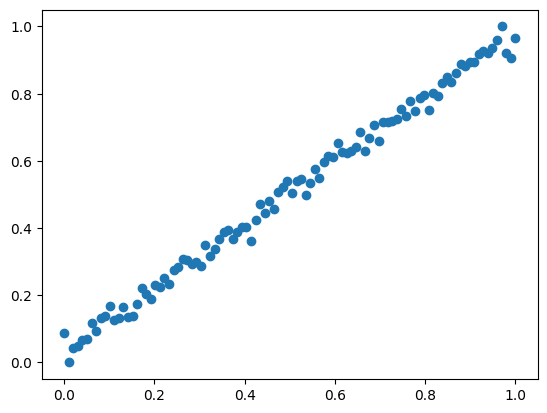

In [12]:
plt.scatter(T,V)

In [7]:
T,V,f=donne_exerce(100,1)

In [8]:
X,Y,Z=Mallaige_de_fonction(T,V,f,n=40)

0.525488044345876 0.25904340063225706


<Figure size 900x300 with 0 Axes>

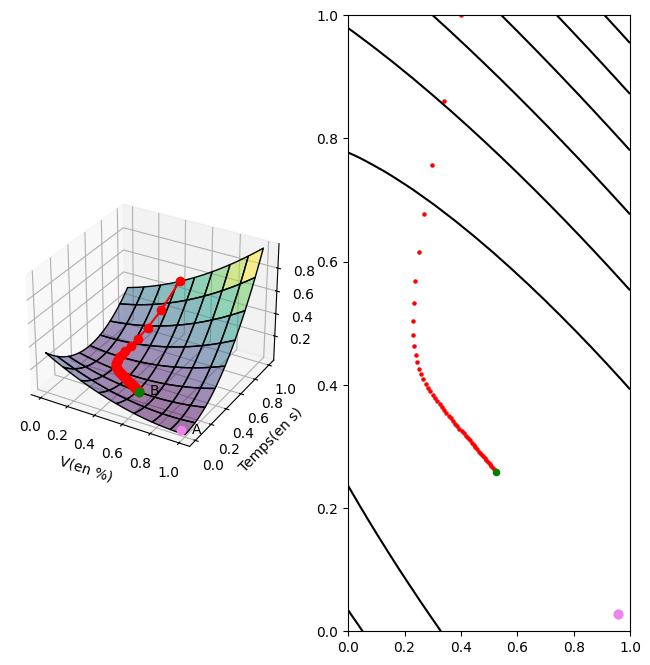

0.9678667200567603 0.08160287534526414


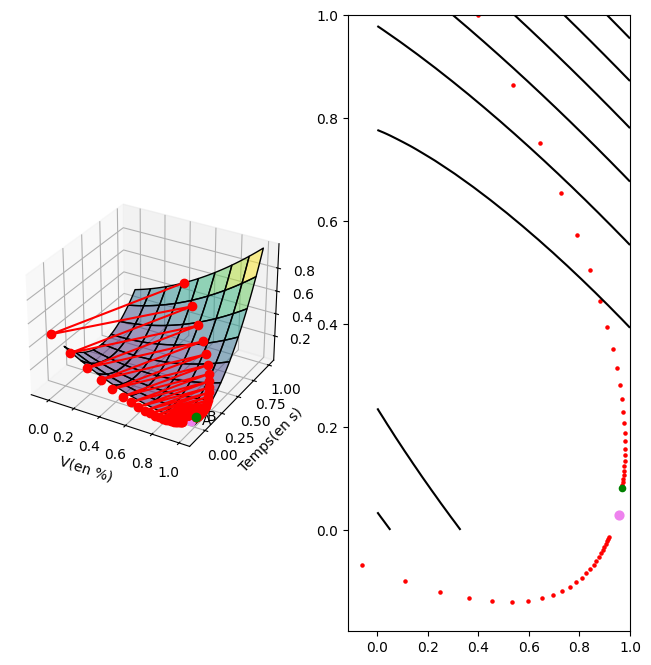

1.2757067353911333 0.6548137872277544


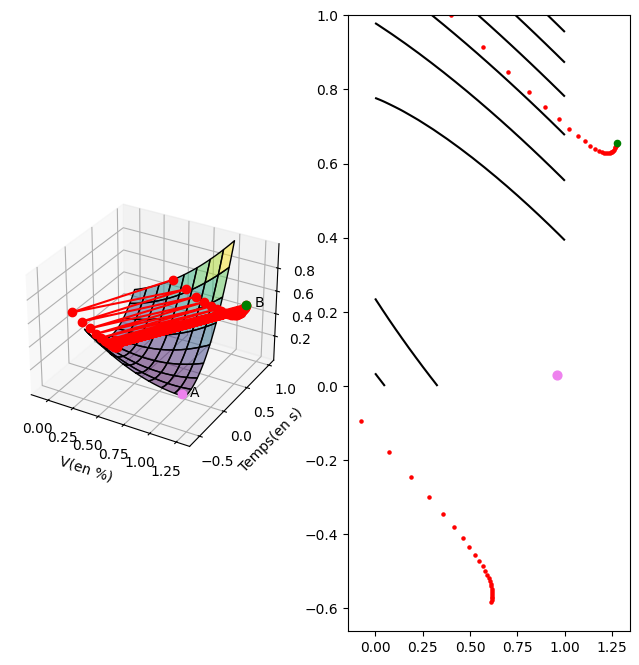

In [9]:
nbr_iter=50
liste_pas=[0.1,0.77,0.79]
fig1=plt.figure(figsize=(9,3))
for i,j in zip(liste_pas,[k for k in range(1,len(liste_pas)+1)]):
    #ax=fig1.add_subplot(1,3,j)
    a,b=GDS(T,V,nbr_iter,i,a=[0.4],b=[1])
    print(a[-1],b[-1])
    c=grapheGDS(T,V,f,X,Y,Z,a,b,j)

In [122]:
a[-1],b[-1]

(1.315051907858031, 0.6140046491319506)

In [114]:
a1=np.cov(T,V)[0,1]/np.var(T)
b1=np.mean(V)-np.mean(T)*a1
a1,b1

(0.994470304448694, 0.004078038860290567)

In [ ]:
## autres

In [31]:
def grapheGDS_ani(a,b,X):
    
    m=len(X)
    k=nbr_iter
    for i in range(1,nbr_iter+1,1):
        #plt.close('all')
        Y2=[a[i]*X[j]+b[i] for j in range(m)]
        fig=plt.figure(figsize=(12,4))
        clear_output(wait=True)
        ax1=fig.add_subplot(1,3,1,projection='3d')
        ax2=fig.add_subplot(1,3,2)
        ax3=fig.add_subplot(1,3,3)
        
                
        ax1.plot_surface(X1,Y1,Z,cmap='viridis',alpha=0.8)
        ax1.scatter(a[:i],b[:i],s=5,c='r')
        ax1.set_xlabel("Quantité de virus en poucentange")
        ax1.set_ylabel("Temps (jours)")
        ax1.set_title("Évolution de J_m")
        fig.tight_layout()
        
        
        ax2.scatter(X[:],Y[:])
        ax2.plot(X,Y2,'r')
        ax2.set_xlabel("Temps (jours)")
        ax2.set_ylabel("Quantité de virus en poucentange")
        ax2.set_title("Les données (t_i,v_i):régression linéaire")
        fig.tight_layout()
        
        ax3.contour(X1,Y1,Z,colors='black')
        ax3.scatter(a[:i],b[:i],s=5,c='r')
        ax3.scatter(a[-1],b[-1],s=20,c='g')
        ax3.set_xlabel("Temps (jours)")
        ax3.set_ylabel("Quantité de virus en poucentange")
        ax3.set_title("Descente du gradient de J_m")

        fig.tight_layout()
        plt.show()
        #plt.close(fig)
        #if k>nbr_iter: k=k-2**k+200
        #else  k=2**k
        fig.savefig('GDS2.png')
        plt.show()
        plt.close(fig)
    return

## Test des fonctions

In [130]:
nbr_iter=30
a1=np.cov(X,Y)[0,1]/np.var(X)
b1=np.mean(Y)-np.mean(X)*a1
a,b=GDS(nbr_iter,pas=0.1,a=[0.6],b=[0.9])

In [131]:
#grapheGDS(a,b,X)
#ani.save('animation.gif',Writer='pillow',dpi=300)

In [212]:
nbr_iter=1000
a,b=GDS(nbr_iter,pas=0.1,a=[0.5],b=[0.9])


Text(0.5, 0.92, 'Descente du gradient de J_m')

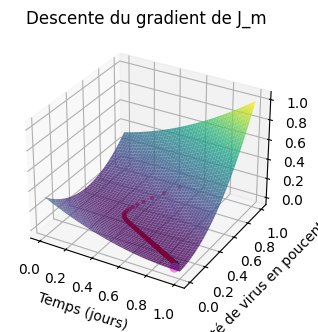

In [214]:
fig=plt.figure(figsize=(12,4))
ax3=fig.add_subplot(1,3,3,projection='3d')
#ax3.grid(False)
#ax3.contour(X1,Y1,Z,colors='black')
ax3.plot_surface(X1,Y1,Z,cmap='viridis',alpha=0.8) #cmap='viridis',edgecolor='k',color='w'
ax3.scatter(a1,b1,f(a1,b1),s=40,c='violet',zorder=10)
ax3.scatter(a[:],b[:],s=5,c='r',zorder=10)
ax3.scatter(a[-1],b[-1],s=20,c='g',zorder=10)
ax3.set_xlabel("Temps (jours)")
ax3.set_ylabel("Quantité de virus en poucentange")
ax3.set_title("Descente du gradient de J_m")


In [180]:
a=np.cov(X,Y)[0,1]/np.var(X)
b=np.mean(Y)-np.mean(X)*a
a,b

(0.9387709092268125, 0.029246251902241005)

In [103]:
c

array([[0.08850479, 0.08142401],
       [0.08142401, 0.07764571]])

In [16]:
#plt.savefig('a0')

## fermé

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Définition de la fonction à minimiser
f=lambda x: x*np.cos(x)-1

# Définition de la dérivée de la fonction
df=lambda x:np.cos(x) -x*np.sin(x)

# Initialisation des paramètres
x0 = 0.5
alpha = 0.01
n_iter = 1000
X,Y=[],[]

# Création de la figure
plt.figure()

# Boucle de minimisation
for i in range(n_iter):
  x = x0 - alpha * df(x0)
  x0 = x
  X.append(x0)
  Y.append(f(x0))
  
  # Affichage de la fonction en temps réel
  x_values = np.linspace(-1,1, 500)
  y_values = f(x_values)
  plt.plot(x_values, y_values, label='Fonction')
  plt.plot(x0, f(x0), 'ro', label='Minimum')
  plt.title('Minimisation de la fonction')
  plt.xlabel('x')
  plt.ylabel('f(x)')
  plt.plot(X,Y,">g")
  plt.legend()
  plt.pause(0.01)
  plt.clf()
  
plt.show()